# Multiple Linear Regression Model: Prediction of the quantity to order

Multiple Linear Regression (MLR) will be used as the baseline predictive model to estimate the quantity of malaria commodities approved by the central supply chain (quantity_approved) from a set of inventory, product, facility, geographic, and temporal predictors. 

Although the exploratory analysis indicated that several predictors do not exhibit strong individual linear relationships with the target, MLR remains valuable because it evaluates their combined linear contribution and provides an interpretable benchmark against which more flexible machine-learning approaches, such as Decision Tree and Random Forest regression, can be compared. 

The analysis will consist of three main stages: 
1. checking model assumptions,
2. building and evaluating the model,
3. and interpreting the model results.

Assumptions that cannot be fully assessed before model estimation—particularly residual normality, homoscedasticity, and residual linearity—will be evaluated after fitting the baseline model.

## Import libraries and loading data

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

# Packages for stats and correlations
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Packages for OLS, MLR, confusion matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics # For confusion matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [92]:
df=pd.read_csv('../data/dataset_model.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product                        8763 non-null   object 
 1   product_group                  8763 non-null   object 
 2   facility_type                  8763 non-null   object 
 3   reporting_month                8763 non-null   object 
 4   High_Transmission_Preparation  8763 non-null   object 
 5   zone_type                      8763 non-null   object 
 6   beginning_balance              8763 non-null   float64
 7   quantity_received              8763 non-null   float64
 8   quantity_dispensed             8763 non-null   float64
 9   total_losses_and_adjustments   8763 non-null   int64  
 10  stock_in_hand                  8763 non-null   float64
 11  months_of_stock                8481 non-null   float64
 12  stock_status                   8763 non-null   o

## 1. Checking Model Assumptions: pre-model checks 

### 1.1. Linearity — preliminary assessment completed during EDA
The expected relationship between the predictors and quantity_approved should be adequately represented by a linear combination of the predictors. The pairplot showed that most continuous predictors do not demonstrate strong simple linear relationships with quantity_approved.
This does not automatically invalidate MLR because the pairplot only examines predictors individually. 

### 1.2. Independence of observations — supported by operational context
Based on your analytical framework, each record represents a particular product observation associated with a requisition/reporting period.

### 1.3. No multicollinearity — test before model fitting
This is your most important remaining pre-model assumption. The EDA already suggested relationships such as AMC and quantity dispensed, Stock in Hand and  Quantity dispensed.
Also engineered variables could create additional expected dependencies. Therefore, some predictors may contain overlapping information.



In [93]:
#Calculate Pearson correlations among continuous predictors:
numerical_features = [
    "beginning_balance",
    "quantity_received",
    "quantity_dispensed",
    "stock_in_hand",
    "total_losses_and_adjustments",
    "amc",
    "months_of_stock"
]
corr_matrix = df[numerical_features].corr()
corr_matrix.round(2)

,beginning_balance,quantity_received,quantity_dispensed,stock_in_hand,total_losses_and_adjustments,amc,months_of_stock
beginning_balance,1.00,0.10,0.72,0.75,-0.06,0.64,-0.07
quantity_received,0.10,1.00,0.24,0.31,0.01,0.21,-0.01
quantity_dispensed,0.72,0.24,1.00,0.69,-0.01,0.87,-0.14
stock_in_hand,0.75,0.31,0.69,1.00,-0.00,0.61,-0.00
total_losses_and_adjustments,-0.06,0.01,-0.01,-0.00,1.00,-0.01,-0.00
amc,0.64,0.21,0.87,0.61,-0.01,1.00,-0.15
months_of_stock,-0.07,-0.01,-0.14,-0.00,-0.00,-0.15,1.00


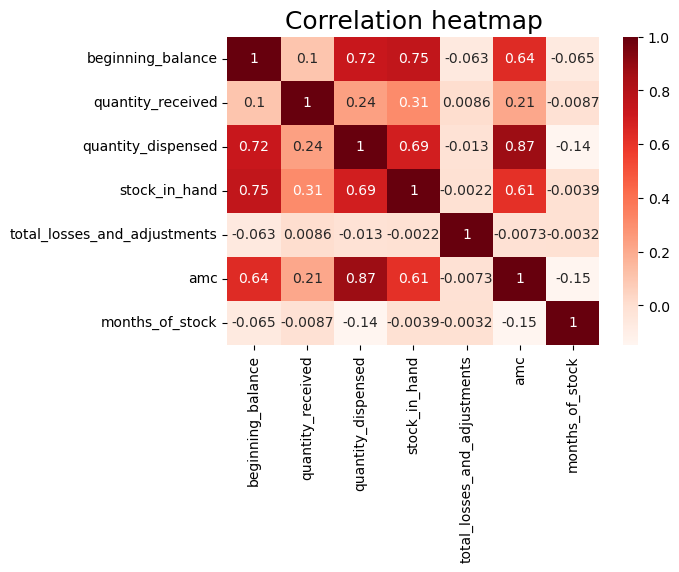

In [94]:
# Create correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[numerical_features].corr(method='pearson'), annot=True, cmap='Reds')
plt.title('Correlation heatmap',
          fontsize=18)
plt.show()

* The correlation analysis identified potential multicollinearity among several inventory-related predictors. The strongest relationship was observed between quantity_dispensed and amc (r = 0.87), which is operationally expected because AMC is derived from historical quantities dispensed
* In contrast, quantity received, losses and adjustments, and Months of Stock showed relatively weak correlations with the other predictors
* AMC has greater operational relevance because it summarizes consumption over three periods rather than a single month and is directly used in inventory planning. **For the modul construction,  quantity_dispensed could be removed** therefore, Variance Inflation Factor (VIF) analysis will be conducted to determine whether the observed relationships result in problematic multicollinearity in the Multiple Linear Regression model.

In [95]:
# Variance Inflation Factor (VIF) analysis
X_vif = df[numerical_features].dropna().copy()
X_vif = sm.add_constant(X_vif)
vif = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
vif

,variable,VIF
0,const,2.093406
1,beginning_balance,3.009352
2,quantity_received,1.178046
3,quantity_dispensed,5.457024
4,stock_in_hand,2.823059
5,total_losses_and_adjustments,1.010031
6,amc,4.185656
7,months_of_stock,1.041185


A VIF of 5.45 is moderate, not catastrophic. So we will keep the variable quantity_dispensed for out model

## 2.Construct the model

After analysis and deriving variables with close relationships, it is time to begin constructing the model

### 2.1. Split data into outcome variable and features

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product                        8763 non-null   object 
 1   product_group                  8763 non-null   object 
 2   facility_type                  8763 non-null   object 
 3   reporting_month                8763 non-null   object 
 4   High_Transmission_Preparation  8763 non-null   object 
 5   zone_type                      8763 non-null   object 
 6   beginning_balance              8763 non-null   float64
 7   quantity_received              8763 non-null   float64
 8   quantity_dispensed             8763 non-null   float64
 9   total_losses_and_adjustments   8763 non-null   int64  
 10  stock_in_hand                  8763 non-null   float64
 11  months_of_stock                8481 non-null   float64
 12  stock_status                   8763 non-null   o

Recall that Input X contains NaN coming from the months_of_stock. LinearRegression does not accept missing values encoded as NaN natively.
I will remove them from the dataset.

In [97]:
df = df.dropna(subset=["months_of_stock"]).copy()
print(df.isna().sum().sum())

0


In [98]:
# Split the model into outcome variable and features
# Remove the target column from the features
retained_features=['product_group','facility_type','reporting_month','zone_type','High_Transmission_Preparation','stock_status',
                  'beginning_balance','quantity_received','quantity_dispensed','total_losses_and_adjustments','stock_in_hand','months_of_stock'
                  ,'amc']
X=df[retained_features]
y=df[['quantity_approved']]

In [99]:
X.head()

,product_group,facility_type,reporting_month,zone_type,High_Transmission_Preparation,stock_status,beginning_balance,quantity_received,quantity_dispensed,total_losses_and_adjustments,stock_in_hand,months_of_stock,amc
0,PYRA,HEALTH CENTER,May,URBAN,YES,Overstock,3510.0,6.0,437.0,246,1426.0,9.4,151.0
1,ACT,HEALTH CENTER,May,URBAN,YES,Adequate,89.0,1.0,57.0,209,65.0,3.2,20.0
2,ACT,HEALTH CENTER,February,RURAL,NO,Adequate,4125.0,2604.0,1423.0,-179,6554.0,4.5,1464.0
4,DIAG,HEALTH CENTER,February,URBAN,NO,Adequate,2243.0,0.0,535.0,420,2167.0,3.7,583.0
5,ACT,HEALTH CENTER,May,RURAL,YES,Overstock,1346.0,0.0,82.0,-278,600.0,18.2,33.0


In [100]:
y.head()

,quantity_approved
0,0.0
1,620.0
2,13.0
4,319.0
5,2.0


### 2.2. Pre-process data

In [101]:
categorical_features = [
    "product_group",
    "facility_type",
    "reporting_month",
    "zone_type",
    "High_Transmission_Preparation",
    "stock_status"
]

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)


In [102]:
X.head()

,beginning_balance,quantity_received,quantity_dispensed,total_losses_and_adjustments,stock_in_hand,months_of_stock,amc,product_group_ART,product_group_DIAG,product_group_PREV,...,facility_type_HOSPITAL,reporting_month_February,reporting_month_May,reporting_month_November,zone_type_URBAN,High_Transmission_Preparation_YES,stock_status_Critical,stock_status_Low,stock_status_Overstock,stock_status_Stockout
0,3510.0,6.0,437.0,246,1426.0,9.4,151.0,0,0,0,...,0,0,1,0,1,1,0,0,1,0
1,89.0,1.0,57.0,209,65.0,3.2,20.0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
2,4125.0,2604.0,1423.0,-179,6554.0,4.5,1464.0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,2243.0,0.0,535.0,420,2167.0,3.7,583.0,0,1,0,...,0,1,0,0,1,0,0,0,0,0
5,1346.0,0.0,82.0,-278,600.0,18.2,33.0,0,0,0,...,0,0,1,0,0,1,0,0,1,0


### 2.3. Split data into training and test sets

Create training and testing sets. The test set should contain 20% of the total samples.

In [103]:
X.head()

,beginning_balance,quantity_received,quantity_dispensed,total_losses_and_adjustments,stock_in_hand,months_of_stock,amc,product_group_ART,product_group_DIAG,product_group_PREV,...,facility_type_HOSPITAL,reporting_month_February,reporting_month_May,reporting_month_November,zone_type_URBAN,High_Transmission_Preparation_YES,stock_status_Critical,stock_status_Low,stock_status_Overstock,stock_status_Stockout
0,3510.0,6.0,437.0,246,1426.0,9.4,151.0,0,0,0,...,0,0,1,0,1,1,0,0,1,0
1,89.0,1.0,57.0,209,65.0,3.2,20.0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
2,4125.0,2604.0,1423.0,-179,6554.0,4.5,1464.0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,2243.0,0.0,535.0,420,2167.0,3.7,583.0,0,1,0,...,0,1,0,0,1,0,0,0,0,0
5,1346.0,0.0,82.0,-278,600.0,18.2,33.0,0,0,0,...,0,0,1,0,0,1,0,0,1,0


In [104]:
X.isna().sum()

beginning_balance                    0
quantity_received                    0
quantity_dispensed                   0
total_losses_and_adjustments         0
stock_in_hand                        0
months_of_stock                      0
amc                                  0
product_group_ART                    0
product_group_DIAG                   0
product_group_PREV                   0
product_group_PYRA                   0
product_group_SP                     0
facility_type_HOSPITAL               0
reporting_month_February             0
reporting_month_May                  0
reporting_month_November             0
zone_type_URBAN                      0
High_Transmission_Preparation_YES    0
stock_status_Critical                0
stock_status_Low                     0
stock_status_Overstock               0
stock_status_Stockout                0
dtype: int64

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

This gives approximately:
* 80% training data
* 20% testing data
The test set should remain untouched until model evaluation.

In [106]:
# Standardize the X variables
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)

Standardization transforms numerical predictors to a common scale with approximately zero mean and unit variance. Although scaling is not required for ordinary Multiple Linear Regression, it facilitates comparison of coefficients across predictors measured on different scales and improves numerical conditioning

### 2.4. Fit the model

In [107]:
# Fit your model to the training data
lr=LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

###  2.5. Evaluate model

We evaluate our model performance by calculating the residual sum of squares and the explained variance score (R^2). We have also calculated the Mean Absolute Error, Mean Squared Error, and the Root Mean Squared Error.

In [108]:
# Evaluate the model performance on the training data
r_sq = lr.score(X_train_scaled, y_train)
print('Coefficient of determination:', r_sq)
y_pred_train = lr.predict(X_train_scaled)
print('R^2:', r2_score(y_train, y_pred_train))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MSE:', mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.14211353764752022
R^2: 0.14211353764752022
MAE: 1016.6572612535709
MSE: 3852310.707645058
RMSE: 1962.7304215416486


* The Multiple Linear Regression model achieved an R² of 0.142, indicating that the selected predictors explain approximately 14.2% of the variation in approved quantities, while most of the variability remains unexplained by the linear model.
* Predictions differ from actual approved quantities by about 1,017 units on average
* The substantially higher RMSE compared with the MAE suggests that the model produces some particularly large prediction errors, which is consistent with the extreme values and highly skewed distribution of quantity_approved identified during the EDA.

Overall, these results indicate that the Multiple Linear Regression model provides limited predictive accuracy for approved quantities. This finding is also consistent with the EDA, which showed weak or non-linear relationships between several individual predictors and the target. The MLR model should therefore be retained as an interpretable baseline, while Decision Tree and Random Forest regression models should be evaluated to determine whether their ability to capture non-linear relationships and interactions can improve predictive performance.

###  2.6. Test data

We calculate the same metrics on the test data. Remember to scale the `X_test` data using the scaler that was fit to the training data. Do not refit the scaler to the testing data, just transform it.

In [109]:
# Scale the X_test data
X_test_scaled = scaler.transform(X_test)

In [110]:
# Evaluate the model performance on the testing data
r_sq_test = lr.score(X_test_scaled, y_test)
print('Coefficient of determination:', r_sq_test)
y_pred_test = lr.predict(X_test_scaled)
print('R^2:', r2_score(y_test, y_pred_test))
print('MAE:', mean_absolute_error(y_test,y_pred_test))
print('MSE:', mean_squared_error(y_test, y_pred_test))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred_test)))

Coefficient of determination: 0.15319986693197107
R^2: 0.15319986693197107
MAE: 1019.583377492636
MSE: 3546251.9215569203
RMSE: 1883.1494687243814


The R² values of 0.142 and 0.153 indicate that the linear model explains only about 14–15% of the variability in approved quantities in both the training and test datasets. The closeness of these values indicates that there is no clear evidence of overfitting: the model does not perform substantially better on the data used for training than on unseen observations.

Similarly, MAE is almost identical between the two datasets—approximately 1,017 units for training and 1,020 units for testing—which reinforces the conclusion that the model generalizes consistently, but at a relatively low level of accuracy.

In [111]:
y_test

,quantity_approved
5142,19.0
3307,331.0
4280,2028.0
8321,385.0
6600,9903.0
...,...
131,3.0
6367,0.0
5532,2967.0
4750,0.0


In [112]:
# Create a `results` dataframe
results = pd.DataFrame(data={'actual': y_test['quantity_approved'],
                             'predicted': y_pred_test.ravel()})
results['residual'] = results['actual'] - results['predicted']
results.head()

,actual,predicted,residual
5142,19.0,192.694201,-173.694201
3307,331.0,915.233163,-584.233163
4280,2028.0,2906.380906,-878.380906
8321,385.0,324.745184,60.254816
6600,9903.0,1085.168953,8817.831047


### 2.7.Visualize model results


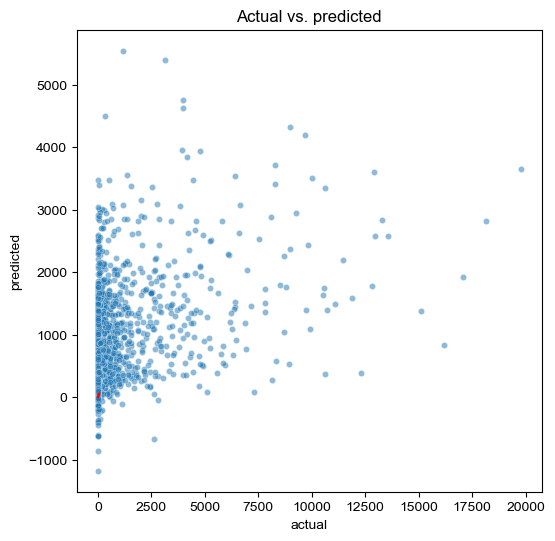

In [124]:
# Create a scatterplot to visualize `predicted` over `actual`
fig, ax = plt.subplots(figsize=(6, 6))
sns.set(style='whitegrid')
sns.scatterplot(x='actual',
                y='predicted',
                data=results,
                s=20,
                alpha=0.5,
                ax=ax
)
# Draw an x=y line to show what the results would be if the model were perfect
plt.plot([0,60], [0,60], c='red', linewidth=2)
plt.title('Actual vs. predicted');

## 2. Checking Model Assumptions: post-model checks

### 2.1. Normality

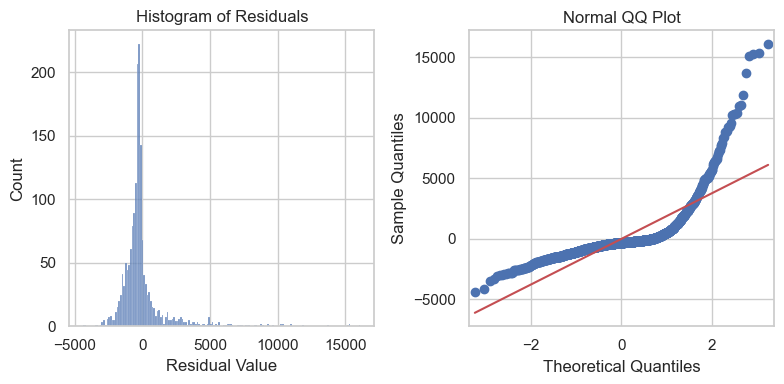

In [126]:
residuals=results['residual']
# Create a 1x2 plot figure.
fig, axes = plt.subplots(1, 2, figsize = (8,4))

# Create a histogram with the residuals. 

### YOUR CODE HERE ### 

sns.histplot(residuals, ax=axes[0])

# Set the x label of the residual plot.
axes[0].set_xlabel("Residual Value")

# Set the title of the residual plot.
axes[0].set_title("Histogram of Residuals")

# Create a Q-Q plot of the residuals.

### YOUR CODE HERE ### 

sm.qqplot(residuals, line='s',ax = axes[1])

# Set the title of the Q-Q plot.
axes[1].set_title("Normal QQ Plot")

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance.
plt.tight_layout()

# Show the plot.
plt.show()

* Histogram of residuals: The residuals are strongly concentrated around zero but exhibit a pronounced right-skewed distribution with a long positive tail. Several very large positive residuals are visible, indicating observations where the model substantially underpredicts the actual approved quantity. The residual distribution is therefore clearly not symmetric or approximately normal
* Q-Q plot: The residuals deviate substantially from the theoretical normality line, particularly in the upper tail. The strong upward departure at high quantiles confirms the presence of large positive residuals and heavy tails. Deviations are also present in the lower tail, although they are less pronounced than in the upper tail.

The graphical residual diagnostics indicate that the normality assumption of the Multiple Linear Regression model is not satisfied.
**The low R², together with the residual pattern suggests that a simple linear specification is not adequately capturing the structure of `quantity_approved`**

## 2.2. Homoscedasticity

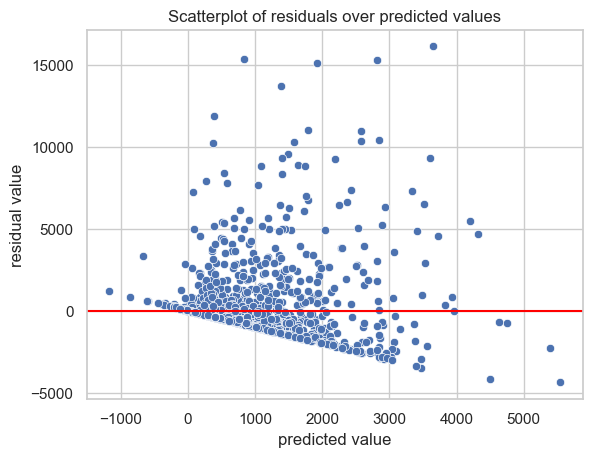

In [127]:
# Create a scatterplot of `residuals` over `predicted`
sns.scatterplot(x='predicted', y='residual', data=results)
plt.axhline(0, c='red')
plt.title('Scatterplot of residuals over predicted values')
plt.xlabel('predicted value')
plt.ylabel('residual value')
plt.show()

* The residuals are not randomly distributed with approximately constant variance around the zero line. Instead, their dispersion increases substantially as the predicted quantity_approved increases
* At lower predicted quantities, residuals are relatively concentrated, whereas at higher predicted quantities they become increasingly dispersed, including several very large positive residuals

This indicates heteroscedasticity, meaning that the variance of the model errors changes across the range of predicted approved quantities.
Combined with our earlier results, the MLR diagnostics now show:
* Low explanatory power: R² ≈ 14.2%.
* Non-normal residuals: histogram and Q-Q plot show strong right-skewness and heavy tails.
* Heteroscedasticity: residual variance changes substantially across fitted values.
* Large prediction errors: particularly for some high-volume approvals.

Therefore, the graphical evidence further suggests that the current linear model does not adequately capture the structure and variability of quantity_approved